In [ ]:
import numpy as np
import matplotlib.pyplot as plt


from background import Background
from matrices import Matrices
from utilities import *
from potential import Potential
from initial import Initial
from evolve import *

Mounted at /content/drive


In [ ]:
# The potential of Equation (9.7). For test
class Eq97Potential(Potential):
    def __init__(self, p, nF):
        Potential.__init__(self, p, nF)
        self.p = p
        self.nF = nF

    def V(self, Q):
        m, c, phi0, d = self.p
        phi = Q[:, 0]
        return (1 / 2) * m**2 * phi**2 * (1 + c * np.tanh((phi - phi0) / d))

    def dV(self, Q):
        m, c, phi0, d = self.p
        phi = Q[:, 0]

        x = (phi - phi0) / d
        term1 = c * m**2 * phi**2 * (1 / np.cosh(x))**2 / (2 * d)
        term2 = m**2 * phi * (1 + c * np.tanh(x))
        return [term1 + term2]

    def ddV(self, Q):
        m, c, phi0, d = self.p
        phi = Q[:, 0]

        x = (phi - phi0) / d
        sech2 = (1 / np.cosh(x)) ** 2
        tanh = np.tanh(x)

        term1 = (4 * c * phi * sech2) / d
        term2 = (2 * c * phi ** 2 * sech2 * tanh) / (d ** 2)
        term3 = 2 * (1 + c * tanh)

        return [[0.5 * m ** 2 * (term1 - term2 + term3)]]

    def dddV(self, Q):
        m, c, phi0, d = self.p
        phi = Q[:, 0]

        x = (phi - phi0) / d
        sech2 = (1 / np.cosh(x)) ** 2
        sech4 = sech2 ** 2
        tanh = np.tanh(x)

        term1 = (6 * c * sech2) / d
        term2 = (12 * c * phi * sech2 * tanh) / (d ** 2)
        term3 = c * phi ** 2 * (
                - (2 * sech4) / (d ** 3)
                + (4 * sech2 * tanh ** 2) / (d ** 3)
        )

        return [[[0.5 * m ** 2 * (term1 - term2 + term3)]]]

In [ ]:
nF = 1
p = [1e-5, 0.0018, 14.84, 0.022]
pot = Eq97Potential(p, nF)
bkg = Background(pot)

N_step = 0.0005
phi_0 = np.array([[16.5, 0]])

N_min = 0
N_max = 40 # End of background fields
N_end = 35 # End of evolution. For all fields
N_pre = 5 # Substracted

In [ ]:
# Part one: Evolve the background field.
# The evolved background can be used throughout

Q_0 = find_Q_0(nF, phi_0, pot, bkg, N_min)
evoF = EvolveFields(nF, N_min, Q_0, pot)
Q_N = evoF.forwardEvolve(N_max, N_step=N_step)

In [ ]:
# kt, alpha and beta parameterization. Eq 9.4
# Note kt=165 for a horizon exit at N=14.8
kt = 165 * 3

def k_alp_be(alpha, beta):
  k1 = kt / 4 * (1 + alpha + beta)
  k2 = kt / 4 * (1 - alpha + beta)
  k3 = kt / 2 * (1 - beta)
  return np.array((k1, k2, k3))

# Calculate the dimensionless B spectrum at given alpha beta

def B_alp_be(alpha, beta):
  k = k_alp_be(alpha, beta)
  k_min = min(k)

  # For way too small k, we don't calculate
  if k_min < 20: return None

  init = Initial(nF, pot, k_min, Q_N, N_pre)
  _, _, N_init, Q_0 = init.get_init()
  Q_evo = Q_N[int(N_init / N_step):]

  # Three sigma needed for final B
  evoS = EvolveSigma(nF, pot)
  sigma_re_0, sigma_im_0 = init.sigma(([k[0], 0, 0]))
  sigma1 = evoS.forwardEvolve(([k[0], 0, 0]), Q_evo, sigma_re_0, sigma_im_0, N_end)

  sigma_re_0, sigma_im_0 = init.sigma(([k[1], 0, 0]))
  sigma2 = evoS.forwardEvolve(([k[1], 0, 0]), Q_evo, sigma_re_0, sigma_im_0, N_end)

  sigma_re_0, sigma_im_0 = init.sigma(([k[2], 0, 0]))
  sigma3 = evoS.forwardEvolve(([k[2], 0, 0]), Q_evo, sigma_re_0, sigma_im_0, N_end)

  evoB = EvolveB(nF, pot)
  B_re_0 = init.B_full(k)
  B = evoB.forwardEvolve(k, Q_evo, (sigma1, sigma2, sigma3), B_re_0, N_end)

  N = B[-1]['N']
  Q = B[-1]['Q']
  B_re = B[-1]['B_re']
  sigma1_re = sigma1[-1]['sigma_re']
  sigma2_re = sigma2[-1]['sigma_re']
  sigma3_re = sigma3[-1]['sigma_re']

  # Dimensionless spectrum
  spec = Spectra(1, pot)
  B_spec = spec.bispectrum(k, Q, B_re, (sigma1_re, sigma2_re, sigma3_re))
  P_1 = spec.spectrum(Q, sigma1_re)
  P_2 = spec.spectrum(Q, sigma2_re)
  P_3 = spec.spectrum(Q, sigma3_re)

  f_NL = (5 / 6) * B_spec / (P_1 * P_2 + P_1 * P_3 + P_2 * P_3)
  dimless_B = (k[0] * k[1] * k[2])**2 * B_spec
  return f_NL, dimless_B

In [ ]:
# Mesh sampling
n_beta = 11
n_alpha = 11

beta_vals = np.linspace(0.0, 1.0, n_beta)

param_list = []
for beta in beta_vals:
  alpha_vals = np.linspace(0, 1 - beta, n_alpha)
  for alpha in alpha_vals:
    param_list.append((alpha, beta))

def compute_B(params):
    alpha, beta = params
    ret = B_alp_be(alpha, beta)
    return (alpha, beta, ret)

In [ ]:
# Triangular sampling
n_beta = 50
delta_alpha = 0.025

beta_vals = np.linspace(0.01, 1 / 3, n_beta)

param_list = []
for beta in beta_vals:
  alpha_vals = np.linspace(0, 1 - 3 * beta, int((1 - 3 * beta) / delta_alpha) + 1)
  for alpha in alpha_vals:
    param_list.append((alpha, beta))

def compute_B(params):
    alpha, beta = params
    ret = B_alp_be(alpha, beta)
    return (alpha, beta, ret)

In [ ]:
print(len(param_list))

996


In [ ]:
from concurrent.futures import ProcessPoolExecutor
from tqdm import tqdm

results = []

with ProcessPoolExecutor(max_workers=42) as executor:
    for res in tqdm(executor.map(compute_B, param_list), total=len(param_list)):
        if res[-1] is not None:
          results.append(res)
          print(res)

  0%|          | 1/996 [03:59<66:16:38, 239.80s/it]

(np.float64(0.0), np.float64(0.01), (2.8045908421311614, np.float64(3.417410072019462e-13)))
(np.float64(0.025526315789473685), np.float64(0.01), (2.5427869020917284, np.float64(3.065875949325868e-13)))
(np.float64(0.05105263157894737), np.float64(0.01), (2.8528001712065136, np.float64(3.3333498573942206e-13)))
(np.float64(0.07657894736842105), np.float64(0.01), (2.5757331522138847, np.float64(2.859109294909413e-13)))
(np.float64(0.10210526315789474), np.float64(0.01), (2.7027285004057333, np.float64(2.7983918803120983e-13)))
(np.float64(0.12763157894736843), np.float64(0.01), (2.852459343135702, np.float64(2.7114792234593716e-13)))


  1%|          | 7/996 [04:01<6:56:20, 25.26s/it]  

(np.float64(0.1531578947368421), np.float64(0.01), (2.7558739407918598, np.float64(2.3746234604728823e-13)))
(np.float64(0.1786842105263158), np.float64(0.01), (2.6488728568629063, np.float64(2.0506557068239902e-13)))
(np.float64(0.20421052631578948), np.float64(0.01), (2.9774064058193312, np.float64(2.0614159943175644e-13)))


  1%|          | 10/996 [04:01<4:14:09, 15.47s/it]

...

(np.float64(0.05938775510204097), np.float64(0.31353741496598636), (6.465402607471556, np.float64(1.2228308318017072e-13)))


100%|█████████▉| 993/996 [1:27:54<00:11,  3.71s/it]

(np.float64(0.0), np.float64(0.3201360544217687), (7.11533653267953, np.float64(1.2144555931071078e-13)))
(np.float64(0.03959183673469391), np.float64(0.3201360544217687), (7.840868599902353, np.float64(1.3912621871215075e-13)))


100%|██████████| 996/996 [1:27:54<00:00,  5.30s/it]

(np.float64(0.0), np.float64(0.326734693877551), (5.7645194065448635, np.float64(9.758030070115104e-14)))
(np.float64(0.0), np.float64(0.3333333333333333), (6.776777655793959, np.float64(1.1438548349631795e-13)))


In [ ]:
import pickle

with open('./results.dat', 'wb') as f:
  pickle.dump(results, f)

In [ ]:
import itertools

def alpha_beta_to_k(alpha, beta):
    k1 = 0.25 * (1 + alpha + beta)
    k2 = 0.25 * (1 - alpha + beta)
    k3 = 0.5  * (1 - beta)
    return (k1, k2, k3)


def k_to_alpha_beta(k1, k2, k3):
    beta  = 1 - 2*k3
    alpha = 2*(k1 - k2)
    return (alpha, beta)


def all_permuted_alpha_beta(alpha, beta):
    k = alpha_beta_to_k(alpha, beta)

    perms = set(itertools.permutations(k))

    results = []
    for k1p, k2p, k3p in perms:
        results.append(k_to_alpha_beta(k1p, k2p, k3p))

    return results

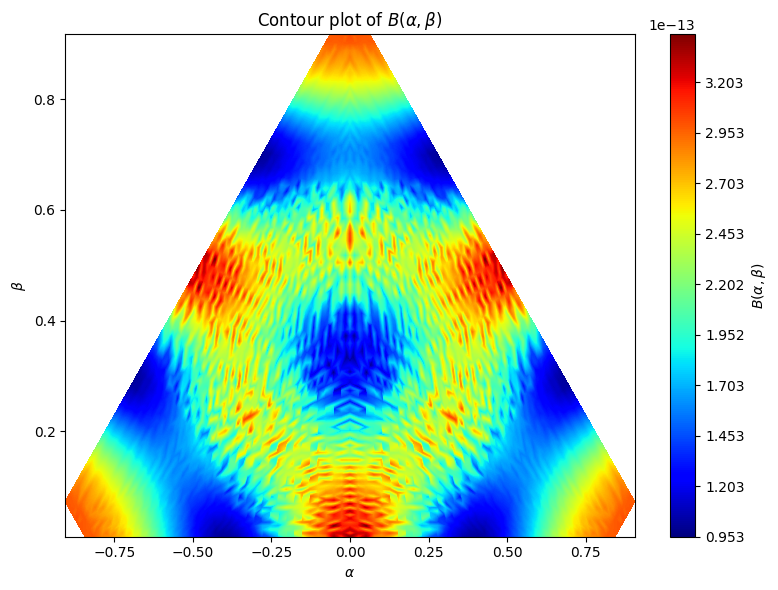

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assume you already have:
# alpha, beta, B (1D arrays)

plt.figure(figsize=(8,6))

alpha = []; beta = []; B_extracted = []
for i in results:
  a = i[0]
  b = i[1]

  # If using mesh sampling, use the following three lines
  # alpha.append(a)
  # beta.append(b)
  # B_extracted.append(i[2][1])

  # Otherwise (trig sampling), use these.
  permu = all_permuted_alpha_beta(a, b)
  for j in permu:
    alpha.append(j[0])
    beta.append(j[1])
    B_extracted.append(i[2][1])

cont = plt.tricontourf(
    alpha,
    beta,
    B_extracted,
    levels=1000,
    cmap="jet"
)

plt.colorbar(cont, label=r"$B(\alpha,\beta)$")
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\beta$")
plt.title(r"Contour plot of $B(\alpha,\beta)$")

plt.tight_layout()
plt.show()

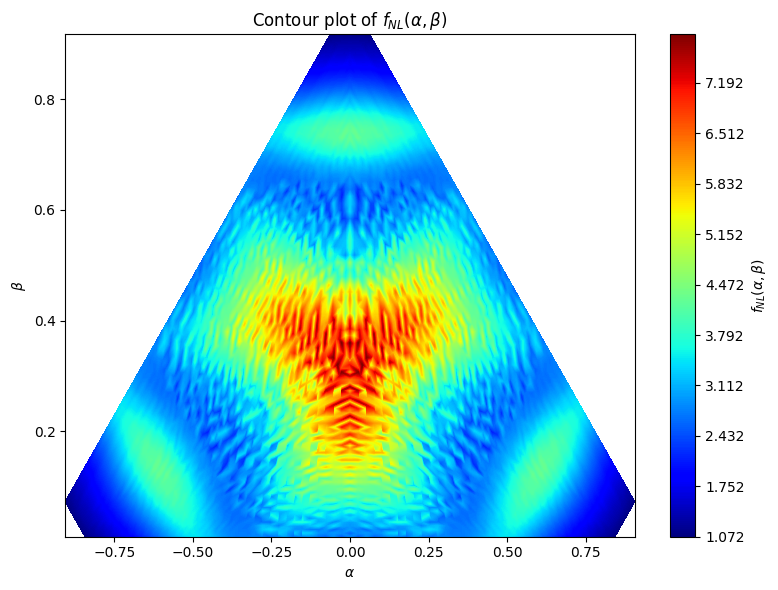

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Assume you already have:
# alpha, beta, B (1D arrays)

plt.figure(figsize=(8,6))

alpha = []; beta = []; B_extracted = []
for i in results:
  a = i[0]
  b = i[1]
  # alpha.append(a)
  # beta.append(b)
  # B_extracted.append(i[2][0])
  permu = all_permuted_alpha_beta(a, b)
  for j in permu:
    alpha.append(j[0])
    beta.append(j[1])
    B_extracted.append(i[2][0])

cont = plt.tricontourf(
    alpha,
    beta,
    B_extracted,
    levels=1000,
    cmap="jet"
)

plt.colorbar(cont, label=r"$f_{NL}(\alpha,\beta)$")
plt.xlabel(r"$\alpha$")
plt.ylabel(r"$\beta$")
plt.title(r"Contour plot of $f_{NL}(\alpha,\beta)$")

plt.tight_layout()
plt.show()